# **KNN 3D Benchmark visual**

This notebook generates heatmap, depicting dependency of MAPE (for chosen ENPH stock) between selected values of <code>k</code> (number of neighbours in k-NN) and <code>p</code> (length of the training sample).

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [3]:
# Dimensions of the heat-map matrix representation
performance_tracker = [[np.nan for j in range(3, 101)] for i in range(1, 101)]

for training_length in range(3, 20 + 1): # p = [3, 20]
    for k in range(1, training_length + 1):
        MAPEs = []
        for ticker in ["ENPH"]:
            # Bounded training-validation set
            Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-07' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
            Stock_Data["Target"] = Stock_Data["Close"].shift(-1)
            Stock_Data = Stock_Data.dropna().reset_index(drop=True)

            prediction_length = 1 # Days
            training_length = training_length

            for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
                if window_start + training_length + prediction_length > len(TrainingDataFrame):
                    continue
                    
                scaler = StandardScaler()

                Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
                Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
            
                Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
                Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

                MODEL = KNeighborsRegressor(n_neighbors=k)

                MODEL.fit(Training_Features, Training_Target)
            
                prediction = MODEL.predict(Test_Features)

                MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        # Tracker
        print(k, training_length, np.mean(MAPEs))
        performance_tracker[k][training_length] = np.mean(MAPEs)

1 3 3.5813186819882747
2 3 4.126173197460997
3 3 4.5984049784350995
1 4 3.5674681196579123
2 4 4.126783058706876
3 4 4.623551607940948
4 4 5.0867559533842535
1 5 3.569568898979088
2 5 4.135109069655694
3 5 4.629128061598464
4 5 5.109521589655769
5 5 5.572694765091436
1 6 3.5699630527233164
2 6 4.115389580054364
3 6 4.626451900088436
4 6 5.152810266456139
5 6 5.5829225654279435
6 6 6.023357088531843
1 7 3.5716513692618466
2 7 4.1019525560652985
3 7 4.625159434360112
4 7 5.144043910543136
5 7 5.594227586837591
6 7 6.057920022820987
7 7 6.4415513779166025
1 8 3.574338842075437
2 8 4.102806138493016
3 8 4.63218753889194
4 8 5.154621439410007
5 8 5.5910570446738985
6 8 6.064872417991726
7 8 6.457301687134021
8 8 6.862412192945399
1 9 3.576534960090794
2 9 4.108745353831897
3 9 4.6413816488057345
4 9 5.157815995466527
5 9 5.624853007552353
6 9 6.075609508119183
7 9 6.480761422603685
8 9 6.8726211809021915
9 9 7.243611003444838
1 10 3.5733511735958037
2 10 4.097823970374617
3 10 4.63877093582

In [4]:
# Localizing minimal value -> irrelevant of p, just k is important
minimum = float("inf")
kde = (-1, -1)
for i in range(len(performance_tracker)):
    for j in range(len(performance_tracker[i])):
        if performance_tracker[i][j] < minimum:
            minimum = performance_tracker[i][j]
            # k, TL
            kde = (i, j)

kde


(1, 12)

In [5]:
# Bounding what to visualize
pt1 = [i[:20] for i in performance_tracker]

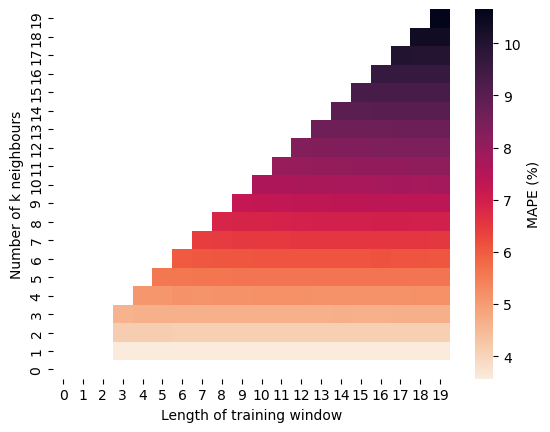

In [12]:
sns.heatmap(
    pt1[:20],
    cmap="rocket_r",
    cbar_kws={
        "label": "MAPE (%)"  # Optional: label for colorbar
    }
).invert_yaxis()

plt.xlabel("Length of training window")
plt.ylabel("Number of k neighbours")
plt.show()